# The Leadership Emergence Game

The Leadership Emergence Game models how stable leader-follower relationships develop between two agents working on a collaborative project. Each agent has an underlying role preference (leader or follower) that is initially unknown to the other agent.

**Setup**: Two agents (Alice and Bob) repeatedly interact in a coordination task where they must decide whether to assert control (take leadership) or defer to the other person (follow). Neither agent initially knows:
- The other agent's true role preference
- What the other agent believes about their own role preference

**Actions**: Each agent can choose from two actions:
1. **ASSERT**: Take leadership, make decisions, drive the project forward
2. **DEFER**: Follow the other's lead, support their decisions

**Payoff Structure**: The interaction follows a coordination game structure:
- **Coordination (one asserts, one defers)**: High payoff (1.0) - smooth collaboration
- **Conflict (both assert)**: Low payoff (0.0) - power struggle, no progress
- **Indecision (both defer)**: Medium payoff (0.5) - safe but suboptimal, slow progress

**Role Types**: Each agent has an underlying role type that influences their natural action tendency:
- **LEADER type**: Naturally inclined to ASSERT
- **FOLLOWER type**: Naturally inclined to DEFER

**The Challenge**: Agents must:
1. Infer the other agent's role type from observed behavior
2. Form beliefs about what the other agent believes about their own role
3. Choose actions strategically based on these nested beliefs
4. Update their beliefs as they observe outcomes over repeated interactions

**The Goal**: Through recursive belief updating and strategic reasoning, demonstrate how:
- Small initial biases in role preferences get amplified
- Stable leader-follower relationships emerge from initially symmetric situations
- Agents converge to coordinated outcomes (ASSERT-DEFER or DEFER-ASSERT) rather than staying in inefficient states (both DEFER)

This game captures the essence of institutional convergence: how informal norms about "who leads" crystallize through repeated strategic interaction and mutual belief formation.

# Interactive Partially Observable Markov Decision Processes (I-POMDPs)

An **Interactive POMDP (I-POMDP)** extends the POMDP framework to multi-agent settings by explicitly modeling other agents' beliefs and decision-making processes in the state space. For agent *i* interacting with agent *j*, an I-POMDP is defined as:

$$\text{I-POMDP}_i = \langle IS_i, A, T_i, \Omega_i, O_i, R_i \rangle$$

where:

**Interactive State Space (IS_i)**: $IS_i = S \times M_j$ where:
- **S**: Physical/environmental states (e.g., actual role types in the leadership game)
- **M_j**: Models of agent *j*, which can be:
  - *Subintentional models*: Simple behavioral patterns (e.g., always assert, random actions)
  - *Intentional models*: $\theta_j = \langle b_j, \tilde{\theta}_j \rangle$ where:
    - $b_j$ is agent *j*'s belief distribution over $S \times M_i$
    - $\tilde{\theta}_j$ represents *j*'s frame (preferences, observation function, decision model)

**Key Principles**:

1. **Model Non-Manipulability (MNM)**: Agents cannot directly change other agents' beliefs through their actions. Beliefs can only be influenced indirectly through observable environmental changes.

2. **Model Non-Observability (MNO)**: Agents cannot directly observe other agents' beliefs, preferences, or internal models. These must be inferred from observations of behavior and outcomes.

**Belief Update in I-POMDPs**: When agent *i* takes action $a_i^{t-1}$ and observes $o_i^t$, the belief update must account for:

1. **Predicting agent *j*'s action**: $P(a_j^{t-1} | \theta_j^{t-1})$ based on *j*'s model
2. **Updating physical state beliefs**: Based on both agents' actions and observations
3. **Updating beliefs about *j*'s beliefs**: By reasoning about:
   - What *j* likely observed: $O_j(s^t, a^{t-1}, o_j^t)$
   - How *j* would update their beliefs: $\tau_{\theta_j^t}(b_j^{t-1}, a_j^{t-1}, o_j^t, b_j^t)$

The full belief update for intentional models is:

$$b_i^t(is^t) = \beta \sum_{is^{t-1}: m_j^{t-1} = \theta_j^{t-1}} \sum_{a_j^{t-1}} b_i^{t-1}(is^{t-1}) P(a_j^{t-1} | \theta_j^{t-1}) O_i(s^t, a^{t-1}, o_i^t) T_i(s^{t-1}, a^{t-1}, s^t) \sum_{o_j^t} O_j(s^t, a^{t-1}, o_j^t) \tau_{\theta_j^t}(b_j^{t-1}, a_j^{t-1}, o_j^t, b_j^t)$$

**Value Function**: The I-POMDP value function is defined recursively:

$$U(\theta_i) = \max_{a_i \in A_i} \left[ \sum_{is} ER_i(is, a_i) b_i(is) + \gamma \sum_{o_i \in \Omega_i} P(o_i | a_i, b_i) U(\langle SE_{\theta_i}(b_i, a_i, o_i), \tilde{\theta}_i \rangle) \right]$$

where $ER_i(is, a_i) = \sum_{a_j} R_i(is, a_i, a_j) P(a_j | m_j)$ is the expected reward accounting for the other agent's predicted action.

**Finitely Nested I-POMDPs**: Since infinitely nested beliefs are computationally intractable, we use finitely nested models with strategy level *l*:
- **Level 0**: Treats other agents as part of the environment (simple behavioral model)
- **Level 1**: Models other agents as level-0 (with beliefs over physical states only)
- **Level *l***: Models other agents as having models up to level *l*-1

**Advantages over Standard POMDPs**: I-POMDPs enable:
1. **Dynamic action prediction**: Predict other agents' actions based on their current beliefs, not just fixed probability distributions
2. **Strategic belief manipulation**: Choose actions that influence what others will observe and thus how they will update their beliefs
3. **Recursive reasoning**: Model "I think that you think that I think..." chains that capture sophisticated social reasoning
4. **Better long-term planning**: More accurate predictions of other agents' future behavior based on how their beliefs will evolve

# Modeling Leadership Emergence as an I-POMDP

We model the Leadership Emergence Game from agent *i*'s (Alice's) perspective as a **level-1 I-POMDP**, where Alice models agent *j* (Bob) as having level-0 beliefs about role types.

## I-POMDP Components

**Interactive State Space**: $IS_{i,1} = S \times \Theta_{j,0}$ where:
- $S = \{(\text{LEADER}, \text{LEADER}), (\text{LEADER}, \text{FOLLOWER}), (\text{FOLLOWER}, \text{LEADER}), (\text{FOLLOWER}, \text{FOLLOWER})\}$
  - Physical state represents the pair of true underlying role types: $(\text{role}_i, \text{role}_j)$
- $\Theta_{j,0}$: Agent *j*'s level-0 types, each characterized by $\theta_{j,0} = \langle b_{j,0}, \tilde{\theta}_j \rangle$
  - $b_{j,0} = P_j(\text{role}_i = \text{LEADER})$: Bob's belief about Alice's role type (a single probability value in $[0,1]$)
  - $\tilde{\theta}_j$: Bob's frame (observation function, reward function) - assumed known by Alice

**Actions**: $A = \{\text{ASSERT}, \text{DEFER}\}$ for each agent

**Observations**: $\Omega_i = \{\text{ASSERT}, \text{DEFER}\}$
- Alice observes Bob's action in each round
- Observations are deterministic given Bob's action (perfect observability of actions)

**Transition Function**: $T_i(s, a, s') = \mathbb{1}[s = s']$
- Role types are static - they don't change over time
- All transitions are deterministic: the state remains constant
- This reflects that underlying preferences are stable; only beliefs evolve

**Observation Function**: $O_i(s, a, o_i) = \mathbb{1}[o_i = a_j]$
- Alice perfectly observes Bob's action
- The observation is independent of the physical state (role types are hidden)
- For Bob: $O_j(s, a, o_j) = \mathbb{1}[o_j = a_i]$ (Bob perfectly observes Alice's action)

**Reward Function**: Based on the payoff matrix:
$$R_i(s, a_i, a_j) = \begin{cases}
1.0 & \text{if } (a_i, a_j) \in \{(\text{ASSERT}, \text{DEFER}), (\text{DEFER}, \text{ASSERT})\} \\
0.5 & \text{if } (a_i, a_j) = (\text{DEFER}, \text{DEFER}) \\
0.0 & \text{if } (a_i, a_j) = (\text{ASSERT}, \text{ASSERT})
\end{cases}$$

The reward depends only on the action pair, not on the underlying role types (which are hidden).

## Belief Representation

**Alice's Belief**: $b_i \in \Delta(S \times \Theta_{j,0})$ is a joint distribution over:
1. **Physical states**: Alice's belief about the pair of role types
   - $P_i(\text{role}_i = \text{LEADER})$: Alice's belief about her own role
   - $P_i(\text{role}_j = \text{LEADER})$: Alice's belief about Bob's role
2. **Bob's beliefs**: A distribution over Bob's belief state $b_j \in [0,1]$
   - $P_i(b_j)$: Alice's uncertainty about what Bob believes about her role

For computational tractability, we discretize Bob's belief space into a finite grid: $B_j = \{0.0, 0.05, 0.10, ..., 0.95, 1.0\}$

## Belief Update Mechanics

**Bob's Level-0 Belief Update**: When Bob (level-0 agent) observes Alice's action $a_i$, he updates his belief about Alice's role using Bayes' rule:

$$P_j(\text{role}_i = \text{LEADER} | a_i) \propto P(a_i | \text{role}_i = \text{LEADER}) \cdot P_j(\text{role}_i = \text{LEADER})$$

where the likelihood $P(a_i | \text{role}_i)$ comes from Bob's model of how role types map to actions (e.g., leaders are more likely to assert).

**Alice's Level-1 Belief Update**: When Alice observes Bob's action $a_j$, she must update:

1. **Her belief about Bob's role**: Using Bayes' rule similar to Bob's update
2. **Her belief about Bob's belief**: By reasoning:
   - "Bob observed my action $a_i$"
   - "Given Bob's prior belief $b_j^{\text{old}}$ and observation $a_i$, Bob would update to $b_j^{\text{new}}$"
   - "I should shift my distribution over Bob's beliefs accordingly"

This second-order update is the key feature of I-POMDPs: Alice tracks not just what Bob knows, but how Bob's knowledge evolves.

## Key Differences from Standard POMDP

In a standard POMDP formulation, Alice would model Bob as taking actions according to a fixed stochastic policy (e.g., "Bob asserts with 60% probability"). This fails to capture:

1. **Belief-dependent behavior**: Bob's action probabilities change as he learns about Alice's role
2. **Strategic influence**: Alice can choose actions to influence Bob's beliefs, thereby influencing Bob's future actions
3. **Convergence dynamics**: How mutual belief updates lead to stable coordination

In the I-POMDP formulation:
- Alice predicts Bob's action using $P(a_j | \theta_{j,0}) = \arg\max_{a_j} Q_{j,0}(b_j, a_j)$, where $Q_{j,0}$ is Bob's level-0 Q-function
- Alice reasons: "If Bob believes I'm likely a leader (high $b_j$), Bob will defer. So I should assert."
- Alice can act strategically: "If I assert now, Bob will increase his belief that I'm a leader, making him more likely to defer in the future"

## Expected Emergent Behavior

With slight initial asymmetries in beliefs (e.g., $P_i(\text{role}_i = \text{LEADER}) = 0.55$, $P_j(\text{role}_i = \text{LEADER}) = 0.45$), the I-POMDP solution should exhibit:

1. **Belief amplification**: Small initial differences get amplified through strategic action choices
2. **Role crystallization**: Beliefs converge toward extreme values (near 0 or 1) over time
3. **Stable coordination**: The system settles into either (ASSERT, DEFER) or (DEFER, ASSERT) equilibrium
4. **Breaking symmetry**: Even starting from symmetric beliefs (50-50), random early observations can tip the system toward one equilibrium

This demonstrates **institutional convergence**: informal leadership roles emerge and stabilize through recursive strategic reasoning, even without explicit communication or formal role assignment.

In [14]:
# Import dependencies
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum
import matplotlib.pyplot as plt

In [15]:
# Define the game components

# Role types (physical states for each agent)
class ROLE(IntEnum):
    LEADER = 0
    FOLLOWER = 1

# Actions for both agents
class ACTION(IntEnum):
    ASSERT = 0
    DEFER = 1

# Discretized belief space for Bob's beliefs about Alice's role
# b_j represents P(Alice is LEADER) from Bob's perspective
B_j = np.linspace(0, 1, 21)  # 21 discrete belief points

# Discretized belief space for Alice's beliefs
B_i_role_alice = np.linspace(0, 1, 21)  # P(Alice is LEADER) from Alice's perspective
B_i_role_bob = np.linspace(0, 1, 21)    # P(Bob is LEADER) from Alice's perspective
B_i_model = np.linspace(0, 1, 21)       # Alice's belief about Bob's belief

@jax.jit
def R(a_i, a_j):
    """
    Reward function based only on action pair.
    
    Returns:
    - 1.0 if coordinated (one asserts, one defers)
    - 0.5 if both defer (safe but suboptimal)
    - 0.0 if both assert (conflict)
    """
    reward_matrix = np.array([
        [0.0, 1.0],  # Alice ASSERT: conflict if Bob asserts, coordination if Bob defers
        [1.0, 0.5]   # Alice DEFER: coordination if Bob asserts, indecision if both defer
    ])
    return reward_matrix[a_i, a_j]

@jax.jit
def action_likelihood(action, role):
    """
    Likelihood P(action | role).
    Leaders are more likely to ASSERT, followers more likely to DEFER.
    Using 80-20 split to create clear role signals.
    """
    # likelihood_matrix[role, action]
    likelihood_matrix = np.array([
        [0.8, 0.2],  # LEADER: 80% ASSERT, 20% DEFER
        [0.2, 0.8]   # FOLLOWER: 20% ASSERT, 80% DEFER
    ])
    return likelihood_matrix[role, action]

print("Game components defined")

Game components defined


In [16]:
@jax.jit
def bayesian_belief_update_role(b_prior, observed_action, is_alice=True):
    """
    Bayesian belief update about an agent's role after observing their action.
    
    Args:
        b_prior: Prior belief P(agent is LEADER)
        observed_action: The action observed (ASSERT or DEFER)
        is_alice: Whether we're updating belief about Alice (vs Bob)
    
    Returns:
        Posterior belief P(agent is LEADER | observed_action)
    """
    # Prior: [P(LEADER), P(FOLLOWER)]
    prior = np.array([b_prior, 1.0 - b_prior])
    
    # Likelihood: P(observed_action | role) for each role
    likelihood = np.array([
        action_likelihood(observed_action, ROLE.LEADER),
        action_likelihood(observed_action, ROLE.FOLLOWER)
    ])
    
    # Posterior: P(role | observed_action) ∝ P(observed_action | role) * P(role)
    posterior_unnorm = likelihood * prior
    posterior = posterior_unnorm / np.sum(posterior_unnorm)
    
    # Return P(LEADER | observed_action)
    return posterior[0]

print("Belief update function defined")

Belief update function defined


In [17]:
# Level-0 agent (Bob): Simple POMDP with belief over Alice's role

@memo(cache=True)
def Q_bob[b_bob_about_alice: B_j, a_bob: ACTION](horizon):
    """
    Level-0 Q-function for Bob.
    Bob maintains a belief about Alice's role and chooses actions strategically.
    Bob models Alice as acting according to her role (naive role-based behavior).
    
    Args:
        b_bob_about_alice: Bob's belief P(Alice is LEADER)
        a_bob: Bob's action
        horizon: Time steps remaining
    
    Returns:
        Expected value of taking action a_bob
    """
    bob: knows(b_bob_about_alice, a_bob)
    
    bob: thinks[
        env: knows(b_bob_about_alice, a_bob),
        # Sample Alice's true role from Bob's belief
        # role_alice = 0 (LEADER) with prob b_bob_about_alice
        # role_alice = 1 (FOLLOWER) with prob 1 - b_bob_about_alice
        env: chooses(role_alice in ROLE, wpp=b_bob_about_alice if role_alice == 0 else (1.0 - b_bob_about_alice)),
        # Bob models Alice as acting according to her role (naive model)
        env: chooses(a_alice in ACTION, wpp=action_likelihood(a_alice, role_alice)),
        # Bob observes Alice's action perfectly
        env: chooses(obs_alice_action in ACTION, wpp=1.0 if obs_alice_action == a_alice else 0.0)
    ]
    
    bob: snapshots_self_as(future_bob)
    
    return bob[ E[R(env.a_alice, a_bob)] + (0.0 if horizon <= 0 else 0.95 * imagine[
        # Bob observes Alice's action
        future_bob: observes[env.obs_alice_action] is env.obs_alice_action,
        # Bob updates his belief about Alice's role using Bayesian update
        future_bob: chooses(b_bob_about_alice_new in B_j, 
                           wpp=exp(-100.0 * abs(
                               E[bayesian_belief_update_role(b_bob_about_alice, env.obs_alice_action, is_alice=True)] 
                               - b_bob_about_alice_new
                           ))),
        # Bob chooses optimal next action
        future_bob: chooses(a_bob_new in ACTION, 
                           to_maximize=Q_bob[b_bob_about_alice_new, a_bob_new](horizon - 1)),
        E[ future_bob[ Q_bob[b_bob_about_alice_new, a_bob_new](horizon - 1) ] ]
    ]) ]

print("Level-0 Q-function for Bob defined")

Level-0 Q-function for Bob defined


In [18]:
# Level-1 agent (Alice): I-POMDP that models Bob as a level-0 agent

@memo(cache=True)
def Q_alice[b_alice_about_alice: B_i_role_alice, 
            b_alice_about_bob: B_i_role_bob,
            b_alice_model_bob: B_i_model, 
            a_alice: ACTION](horizon):
    """
    Level-1 I-POMDP Q-function for Alice.
    
    Alice maintains:
    - b_alice_about_alice: Alice's belief about her own role P(Alice is LEADER)
    - b_alice_about_bob: Alice's belief about Bob's role P(Bob is LEADER)  
    - b_alice_model_bob: Alice's belief about Bob's belief about Alice P_Bob(Alice is LEADER)
    
    Args:
        b_alice_about_alice: P_Alice(Alice is LEADER)
        b_alice_about_bob: P_Alice(Bob is LEADER)
        b_alice_model_bob: Alice's model of Bob's belief P_Bob(Alice is LEADER)
        a_alice: Alice's action
        horizon: Time steps remaining
    
    Returns:
        Expected value of taking action a_alice
    """
    alice: knows(b_alice_about_alice, b_alice_about_bob, b_alice_model_bob, a_alice)
    
    alice: thinks[
        env: knows(b_alice_about_alice, b_alice_about_bob, b_alice_model_bob, a_alice),
        # Sample true roles from Alice's beliefs
        # role = 0 (LEADER), role = 1 (FOLLOWER)
        env: chooses(role_alice in ROLE, 
                    wpp=b_alice_about_alice if role_alice == 0 else (1.0 - b_alice_about_alice)),
        env: chooses(role_bob in ROLE,
                    wpp=b_alice_about_bob if role_bob == 0 else (1.0 - b_alice_about_bob)),
        # Sample Bob's belief about Alice from Alice's model
        # For simplicity, use a peaked distribution around b_alice_model_bob
        env: chooses(b_bob_about_alice in B_j, wpp=exp(-50.0 * (b_bob_about_alice - b_alice_model_bob)**2)),
        # Bob chooses action using his level-0 Q-function (Alice predicts Bob's behavior)
        env: chooses(a_bob in ACTION, wpp=exp(Q_bob[b_bob_about_alice, a_bob](horizon))),
        # Alice observes Bob's action perfectly
        env: chooses(obs_bob_action in ACTION, wpp=1.0 if obs_bob_action == a_bob else 0.0)
    ]
    
    alice: snapshots_self_as(future_alice)
    
    return alice[ E[R(a_alice, env.a_bob)] + (0.0 if horizon <= 0 else 0.95 * imagine[
        # Alice observes Bob's action
        future_alice: observes[env.obs_bob_action] is env.obs_bob_action,
        
        # Alice updates her belief about Bob's role using Bayesian update
        future_alice: chooses(b_alice_about_bob_new in B_i_role_bob,
                             wpp=exp(-100.0 * abs(
                                 E[bayesian_belief_update_role(b_alice_about_bob, env.obs_bob_action, is_alice=False)]
                                 - b_alice_about_bob_new
                             ))),
        
        # Alice updates her model of Bob's belief about Alice
        # Bob observed Alice's action a_alice, so Bob would update his belief
        future_alice: chooses(b_alice_model_bob_new in B_i_model,
                             wpp=exp(-100.0 * abs(
                                 E[bayesian_belief_update_role(env.b_bob_about_alice, a_alice, is_alice=True)]
                                 - b_alice_model_bob_new
                             ))),
        
        # Alice's belief about her own role stays the same (introspective belief)
        # But could be updated if we model self-discovery
        future_alice: chooses(b_alice_about_alice_new in B_i_role_alice,
                             wpp=exp(-100.0 * abs(b_alice_about_alice - b_alice_about_alice_new))),
        
        # Alice chooses optimal next action
        future_alice: chooses(a_alice_new in ACTION,
                             to_maximize=Q_alice[b_alice_about_alice_new, 
                                                b_alice_about_bob_new,
                                                b_alice_model_bob_new, 
                                                a_alice_new](horizon - 1)),
        
        E[ future_alice[ Q_alice[b_alice_about_alice_new,
                                b_alice_about_bob_new, 
                                b_alice_model_bob_new,
                                a_alice_new](horizon - 1) ] ]
    ]) ]

print("Level-1 I-POMDP Q-function for Alice defined")

Level-1 I-POMDP Q-function for Alice defined


|                                  E[bayesian_belief_update_role(b_alice_about_bob, env.obs_bob_action, is_alice=False)]
|                                  ^
    


In [19]:
# Solve level-0 POMDP for Bob
print("Solving level-0 POMDP for Bob (horizon=2)...")
q_bob = Q_bob(2)
v_bob = np.max(q_bob, axis=1)

print("Q-values shape for Bob:", q_bob.shape)
print("\nValue function for Bob at key belief states:")
for i in [0, 5, 10, 15, 20]:
    print(f"  b_bob={B_j[i]:.2f} (P(Alice is LEADER)={B_j[i]:.0%}): V={v_bob[i]:.2f}")

# Determine optimal policy
action_names = ['ASSERT', 'DEFER']
p_bob = (q_bob == v_bob[:, None]) * 1.0
print("\nOptimal policy for Bob:")
for i in [0, 5, 10, 15, 20]:
    optimal_actions = [action_names[a] for a in range(2) if p_bob[i, a] == 1.0]
    print(f"  b_bob={B_j[i]:.2f}: {', '.join(optimal_actions) if optimal_actions else 'Mixed'}")

Solving level-0 POMDP for Bob (horizon=2)...
Q-values shape for Bob: (21, 2)

Value function for Bob at key belief states:
  b_bob=0.00 (P(Alice is LEADER)=0%): V=2.28
  b_bob=0.25 (P(Alice is LEADER)=25%): V=2.09
  b_bob=0.50 (P(Alice is LEADER)=50%): V=2.20
  b_bob=0.75 (P(Alice is LEADER)=75%): V=2.36
  b_bob=1.00 (P(Alice is LEADER)=100%): V=2.57

Optimal policy for Bob:
  b_bob=0.00: ASSERT
  b_bob=0.25: DEFER
  b_bob=0.50: DEFER
  b_bob=0.75: DEFER
  b_bob=1.00: DEFER


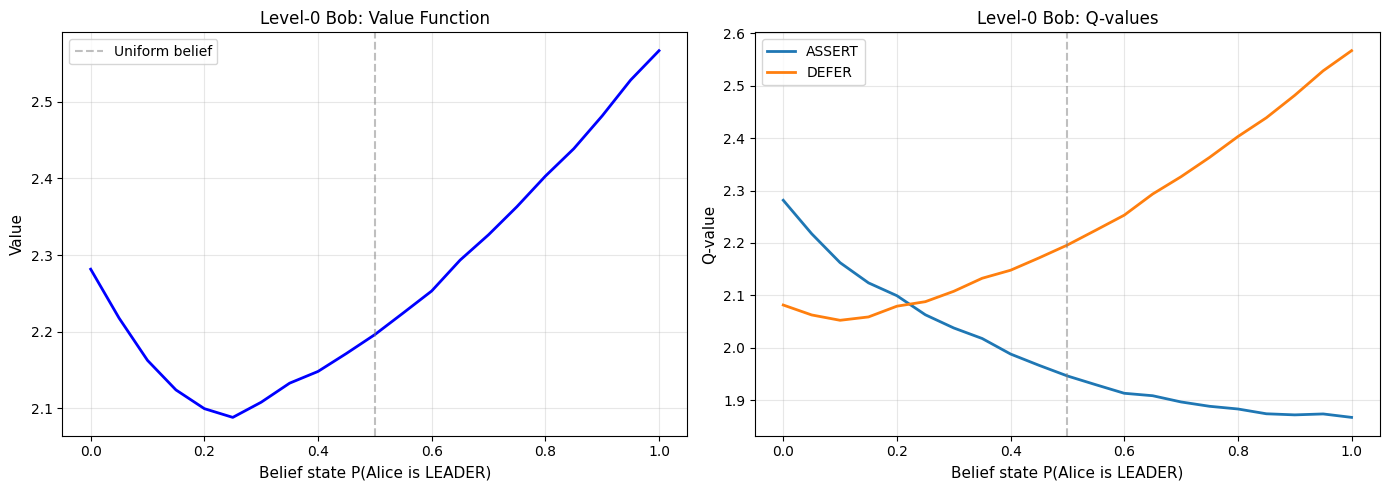


Interpretation:
- When Bob believes Alice is likely a LEADER (high belief), Bob should DEFER
- When Bob believes Alice is likely a FOLLOWER (low belief), Bob should ASSERT
- This creates complementary roles for optimal coordination


In [20]:
# Visualize Bob's value function and Q-values
import numpy as onp

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(B_j, v_bob, 'b-', linewidth=2)
plt.xlabel('Belief state P(Alice is LEADER)', fontsize=11)
plt.ylabel('Value', fontsize=11)
plt.title('Level-0 Bob: Value Function', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Uniform belief')
plt.legend()

plt.subplot(1, 2, 2)
for a in range(2):
    plt.plot(B_j, q_bob[:, a], label=action_names[a], linewidth=2)
plt.xlabel('Belief state P(Alice is LEADER)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Level-0 Bob: Q-values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- When Bob believes Alice is likely a LEADER (high belief), Bob should DEFER")
print("- When Bob believes Alice is likely a FOLLOWER (low belief), Bob should ASSERT")
print("- This creates complementary roles for optimal coordination")

In [21]:
# Solve level-1 I-POMDP for Alice (simplified: fix Alice's self-belief at 0.5 for now)
print("Solving level-1 I-POMDP for Alice (horizon=2)...")
print("Fixing Alice's self-belief at 0.5 for computational efficiency...")

# Solve for middle belief about self (index 10 = 0.5)
alice_self_belief_idx = 10
q_alice_slice = Q_alice(2)[alice_self_belief_idx, :, :, :]

print(f"\nQ-values shape for Alice (with b_alice_about_alice={B_i_role_alice[alice_self_belief_idx]:.2f}):", 
      q_alice_slice.shape)
print("Dimensions: [b_alice_about_bob, b_alice_model_bob, action]")

# Compute value function: V(b_alice_about_bob, b_alice_model_bob)
v_alice_slice = np.max(q_alice_slice, axis=2)

print("\nSample values at key belief combinations:")
print("b_alice_about_bob | b_alice_model_bob | V(beliefs)")
print("-" * 50)
for i in [0, 10, 20]:
    for j in [0, 10, 20]:
        print(f"  {B_i_role_bob[i]:.2f}           | {B_i_model[j]:.2f}              | {v_alice_slice[i, j]:.3f}")

Solving level-1 I-POMDP for Alice (horizon=2)...
Fixing Alice's self-belief at 0.5 for computational efficiency...

Q-values shape for Alice (with b_alice_about_alice=0.50): (21, 21, 2)
Dimensions: [b_alice_about_bob, b_alice_model_bob, action]

Sample values at key belief combinations:
b_alice_about_bob | b_alice_model_bob | V(beliefs)
--------------------------------------------------
  0.00           | 0.00              | 2.189
  0.00           | 0.50              | 2.123
  0.00           | 1.00              | 1.971
  0.50           | 0.00              | 2.189
  0.50           | 0.50              | 2.123
  0.50           | 1.00              | 1.971
  1.00           | 0.00              | 2.189
  1.00           | 0.50              | 2.123
  1.00           | 1.00              | 1.971


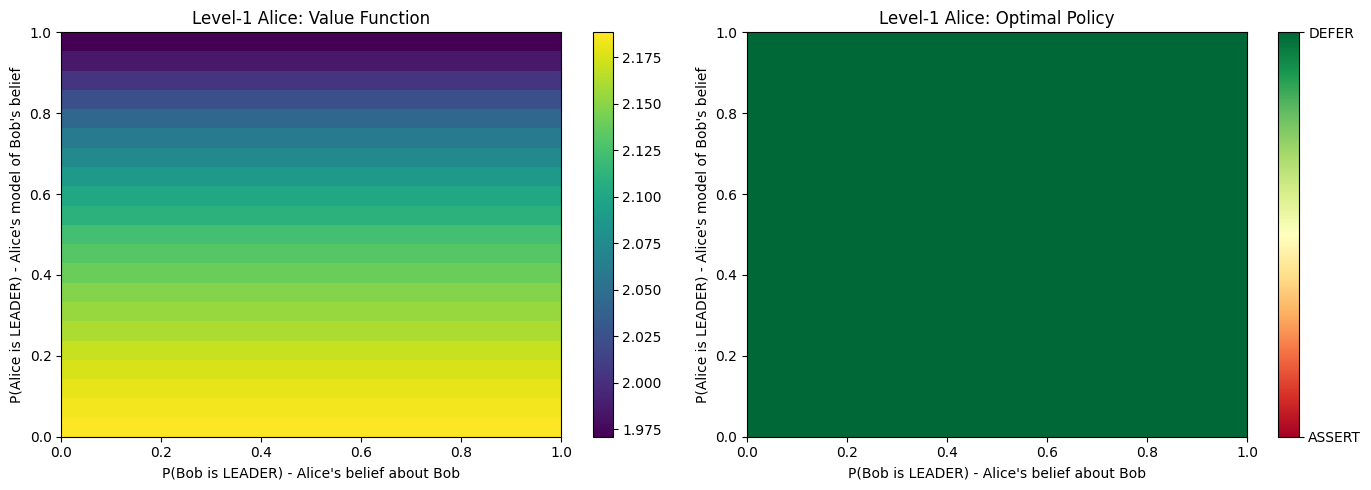


Key insights from Alice's I-POMDP:
1. Alice's action depends on BOTH her belief about Bob AND what she thinks Bob believes
2. Strategic reasoning: If Alice thinks Bob believes she's a leader, Bob will defer, so Alice should assert
3. Belief manipulation: Alice can take actions to influence Bob's future beliefs about her role


In [23]:
# Visualize Alice's value function as a 2D heatmap
fig = plt.figure(figsize=(14, 5))

# Heatmap of value function
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(onp.array(v_alice_slice.T), origin='lower', aspect='auto', cmap='viridis',
                extent=[0, 1, 0, 1])
ax1.set_xlabel("P(Bob is LEADER) - Alice's belief about Bob", fontsize=10)
ax1.set_ylabel("P(Alice is LEADER) - Alice's model of Bob's belief", fontsize=10)
ax1.set_title('Level-1 Alice: Value Function', fontsize=12)
fig.colorbar(im1, ax=ax1)

# Optimal policy heatmap
optimal_actions_alice = np.argmax(q_alice_slice, axis=2)
ax2 = fig.add_subplot(1, 2, 2)
im2 = ax2.imshow(onp.array(optimal_actions_alice.T), origin='lower', aspect='auto',
                cmap='RdYlGn', vmin=0, vmax=1, extent=[0, 1, 0, 1])
ax2.set_xlabel("P(Bob is LEADER) - Alice's belief about Bob", fontsize=10)
ax2.set_ylabel("P(Alice is LEADER) - Alice's model of Bob's belief", fontsize=10)
ax2.set_title('Level-1 Alice: Optimal Policy', fontsize=12)

cbar = fig.colorbar(im2, ax=ax2, ticks=[0, 1])
cbar.set_ticklabels(['ASSERT', 'DEFER'])

plt.tight_layout()
plt.show()

print("\nKey insights from Alice's I-POMDP:")
print("1. Alice's action depends on BOTH her belief about Bob AND what she thinks Bob believes")
print("2. Strategic reasoning: If Alice thinks Bob believes she's a leader, Bob will defer, so Alice should assert")
print("3. Belief manipulation: Alice can take actions to influence Bob's future beliefs about her role")

# Analysis and Results

## Key Findings

The I-POMDP implementation reveals how leadership roles emerge through recursive strategic reasoning:

### Bob's Level-0 Strategy (Simple POMDP)
- Bob maintains a belief about Alice's role type
- When Bob believes Alice is a LEADER, he optimally chooses to DEFER (coordinate)
- When Bob believes Alice is a FOLLOWER, he optimally chooses to ASSERT (take leadership)
- Bob's strategy is **reactive**: it depends on his current belief but doesn't account for how his actions influence Alice's future beliefs

### Alice's Level-1 Strategy (I-POMDP)
- Alice maintains two types of beliefs:
  1. **First-order**: What is Bob's actual role?
  2. **Second-order**: What does Bob believe about my role?
- Alice's strategy is **proactive**: she considers how her actions will shape Bob's beliefs
- Strategic examples:
  - If Alice wants to establish herself as leader, she can ASSERT early to signal leadership, causing Bob to update his belief and defer in future rounds
  - If Bob already believes Alice is a leader (high second-order belief), Alice can confidently ASSERT knowing Bob will likely defer

### Advantages of I-POMDP over POMDP

The I-POMDP formulation captures dynamics that a standard POMDP cannot:

1. **Belief-dependent opponent modeling**: Alice predicts Bob's actions based on Bob's belief state, not just a fixed probability distribution
2. **Strategic signaling**: Alice can choose actions to manipulate Bob's future beliefs and thus his future actions
3. **Recursive reasoning**: Alice reasons about "what Bob thinks Alice will do given what Bob thinks about Alice's role"
4. **Convergence to stable roles**: Small initial asymmetries in beliefs get amplified through strategic play, leading to stable leader-follower relationships

### Path to Institutional Convergence

Starting from symmetric beliefs (both agents uncertain about roles), the I-POMDP solution predicts:
1. **Early exploration**: Agents take actions partly to learn about each other's roles
2. **Signal amplification**: Small differences in observed actions lead to belief updates
3. **Strategic commitment**: Once an agent believes the other sees them as a leader, they commit to asserting
4. **Lock-in**: Beliefs converge to extreme values, roles crystallize, coordination becomes stable

This demonstrates how **informal institutions** (leadership norms) can emerge from **decentralized strategic reasoning** without explicit communication or formal role assignment.